In [8]:
# Cell 1: Core Imports

# Standard Library Imports
import os       # For file path operations and environment variables
import json     # For parsing JSON-formatted UI layout data

# Scientific Computing
import numpy as np   # Numerical operations and array processing
import pandas as pd  # Data manipulation and analysis with DataFrames

# Density-based clustering algorithm
from sklearn.cluster import DBSCAN  

# Data Processing
from collections import Counter    # For counting UI element classes/types
from tqdm import tqdm             # Progress bars for data loading loops

# Visualization
import matplotlib.pyplot as plt   

# Note: These imports support the complete workflow:
# 1. Data loading (json, os)
# 2. Analysis (np, pd, DBSCAN)
# 3. Visualization (plt)
# 4. Progress tracking (tqdm)
# 5. Element counting (Counter)

In [9]:
# Cell 2: Data Loading
def load_rico_data(limit=500, dataset_type='raw'):
    """Loads RICO dataset screens with comprehensive error handling
    
    Args:
        limit: Maximum number of screens to load
        dataset_type: 'raw' or 'annotated' dataset version
    
    Returns:
        List of screen dictionaries with elements and metadata
    """
    screens = []  # Stores all loaded screen data
    
    if dataset_type == 'annotated':
        # Path to annotated dataset in Kaggle
        path = '/kaggle/input/annotated-rico-dataset/rico_semantics-main/data/grouping/train.json'
        try:
            with open(path) as f:
                # Load first screens from JSON file
                for screen in json.load(f)[:limit]:
                    elements = []  # Stores UI elements for current screen
                    
                    # Process each UI element in the screen
                    for elem in screen.get('screen_elements', []):
                        try:
                            # Calculate center coordinates and store element data
                            elements.append({
                                'x': (elem['xmin'] + elem['xmax']) / 2,  # X center
                                'y': (elem['ymin'] + elem['ymax']) / 2,  # Y center
                                'class': elem.get('label', 'UNLABELED'),  # Element type
                                'bounds': [elem['xmin'], elem['ymin'], elem['xmax'], elem['ymax']]  # Coordinates
                            })
                        except KeyError:
                            continue  # Skip elements with missing coordinates
                    
                    # Only add screens with valid elements
                    if elements:
                        screens.append({
                            'screen_id': screen.get('screen_id', str(len(screens))),  # Unique ID or fallback
                            'source': 'annotated',
                            'elements': elements,
                            'element_count': len(elements)  # Total elements in screen
                        })
        except Exception as e:
            print(f"Error loading annotated data: {str(e)}")
    
    else:  # Raw data processing
        raw_path = '/kaggle/input/rico-dataset/unique_uis/combined'
        try:
            # Get first JSON files from directory
            files = [f for f in os.listdir(raw_path) if f.endswith('.json')][:limit]
            
            # Process files with progress bar
            for file in tqdm(files, desc="Loading raw screens"):
                try:
                    with open(os.path.join(raw_path, file)) as f:
                        screen = json.load(f)
                        elements = []
                        
                        if 'activity' in screen:
                            # Recursive function to extract nested UI elements
                            def extract_elements(node):
                                if 'bounds' in node:
                                    try:
                                        bounds = node['bounds']
                                        # Store element data with simplified class name
                                        elements.append({
                                            'x': (bounds[0] + bounds[2]) / 2,
                                            'y': (bounds[1] + bounds[3]) / 2,
                                            'class': node.get('class', 'UNKNOWN').split('.')[-1],  # Remove package prefix
                                            'bounds': bounds
                                        })
                                    except (TypeError, IndexError):
                                        pass  # Skip invalid coordinates
                                # Process child elements recursively
                                for child in node.get('children', []):
                                    extract_elements(child)
                            
                            # Start extraction from root node
                            extract_elements(screen['activity']['root'])
                            
                            if elements:
                                screens.append({
                                    'screen_id': file.split('.')[0],  # Use filename as ID
                                    'source': 'raw',
                                    'elements': elements,
                                    'element_count': len(elements)
                                })
                except Exception as e:
                    print(f"Skipping {file}: {str(e)}")  # Log bad files
        except Exception as e:
            print(f"Error accessing raw data: {str(e)}")
    
    # Final status message
    print(f"✅ Loaded {len(screens)} {dataset_type} screens")
    return screens

In [10]:
# Cell 3: Cognitive Load Analysis
def analyze_cognitive_load(screens):
    """Calculates UI cognitive load metrics including density and element clustering
    
    Args:
        screens: List of screen dictionaries containing UI elements
        
    Returns:
        DataFrame with metrics for each screen:
        - screen_id: Unique identifier
        - source: Dataset origin ('raw' or 'annotated')
        - original_elements: Total UI elements
        - density: Elements per screen area
        - noise_ratio: Percentage of unclustered elements
        - cluster_count: Number of element clusters
    """
    metrics = []  # Stores calculated metrics for all screens
    
    for screen in screens:
        try:
            # Convert element positions to numpy array for processing
            # Array shape: [n_elements, 2] where columns are x,y coordinates
            coords = np.array([[e['x'], e['y']] for e in screen['elements']])
            
            # Cluster elements using DBSCAN algorithm:
            # - eps=0.15: Maximum distance between points in same cluster
            # - min_samples=2: Minimum points to form a cluster
            clustering = DBSCAN(eps=0.15, min_samples=2).fit(coords)
            
            # Analyze clustering results
            cluster_stats = Counter(clustering.labels_)  # Count points per cluster
            noise_ratio = cluster_stats.get(-1, 0) / len(screen['elements'])  # -1 = noise points
            cluster_count = len(cluster_stats) - (1 if -1 in cluster_stats else 0)  # Exclude noise
            
            # Calculate screen space density
            bounds = np.array([e['bounds'] for e in screen['elements']])  # Get all element boundaries
            max_x, max_y = bounds[:, 2].max(), bounds[:, 3].max()  # Screen dimensions
            screen_area = max(max_x * max_y, 1)  # Prevent division by zero for empty screens
            density = len(screen['elements']) / screen_area  # Elements per unit area
            
            # Store metrics for current screen
            metrics.append({
                'screen_id': screen['screen_id'],
                'source': screen['source'],
                'original_elements': len(screen['elements']),
                'density': density,
                'noise_ratio': noise_ratio,
                'cluster_count': cluster_count
            })
            
        except Exception as e:
            print(f"Skipping screen {screen.get('screen_id', '?')}: {str(e)}")
            continue
    
    # Convert results to DataFrame for easier analysis
    return pd.DataFrame(metrics)

In [11]:
# Cell 4: Visualization of Cognitive Load Metrics
def visualize_load_metrics(metrics_df):
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset type with different colors/markers
    for source, group in metrics_df.groupby('source'):
        # Create scatter plot for this dataset:
        # - x-axis: Element density
        # - y-axis: Noise ratio 
        # - alpha: Transparency for overlapping points
        # - label: For the legend
        plt.scatter(group['density'], group['noise_ratio'], 
                   alpha=0.5, label=source)
    
    # Configure plot labels and appearance
    plt.xlabel('Element Density (elements/pixel)')  # X-axis label
    plt.ylabel('Noise Ratio')                      # Y-axis label
    plt.title('Cognitive Load Metrics by Dataset')  # Plot title
    plt.legend()                                   # Show dataset legend
    plt.grid(True)                                 # Add background grid
    plt.show()                                     # Display the plot

In [18]:
# Cell 5: Threshold Optimization with Configurable Parameters
def optimize_pruning_thresholds(metrics_df, params=None):
    """Optimizes pruning thresholds based on cognitive load metrics
    
    Args:
        metrics_df: DataFrame containing screen metrics from analyze_cognitive_load()
        params: Optional dictionary overriding default optimization parameters:
               - density_range: (min, max) bounds for density threshold search
               - noise_range: (min, max) bounds for noise threshold search  
               - min_samples: Minimum screens needed to evaluate a threshold pair
               - reduction_weight: Importance of element reduction vs coverage [0-1]
    
    Returns:
        DataFrame with optimal threshold configuration containing:
        - density_threshold: Maximum allowed element density
        - cluster_threshold: Maximum allowed noise ratio
        - screens_retained: Number of screens meeting thresholds
        - avg_reduction: Average element reduction percentage
        - score: Optimization score (higher is better)
    """
    
    # Filter to only raw screens 
    raw_metrics = metrics_df[metrics_df['source'] == 'raw']
    if len(raw_metrics) < 10:
        raise ValueError("Insufficient raw screens (<10) for reliable optimization")
    
    # Set default parameters if none provided
    default_params = {
        'density_range': (0.02, 0.25),  # Reasonable density bounds for mobile UIs
        'noise_range': (0.2, 0.7),      # Noise ratio search range
        'min_samples': 10,               # Need at least 10 screens per threshold
        'reduction_weight': 0.7,         # 70% weight to reduction
    }
    params = params or default_params
    
    # Create threshold search grid
    density_thresholds = np.linspace(*params['density_range'], 10)  
    noise_thresholds = np.linspace(*params['noise_range'], 10)      
    
    # Evaluate all threshold combinations
    results = []
    for density in density_thresholds:
        for noise in noise_thresholds:
            # Find screens meeting both thresholds
            subset = raw_metrics[
                (raw_metrics['density'] <= density) & 
                (raw_metrics['noise_ratio'] <= noise)
            ]
            
            # Evaluate if enough screens meet criteria
            if len(subset) >= params['min_samples']:
                # Calculate element reduction 
                reduction = 1 - subset['original_elements'].mean() / raw_metrics['original_elements'].mean()
                
                # Calculate coverage 
                coverage = len(subset) / len(raw_metrics)
                
                # Combined score (weighted average)
                score = (reduction * params['reduction_weight'] +
                         coverage * (1 - params['reduction_weight']))
                
                results.append({
                    'source': 'raw',
                    'density_threshold': round(density, 4),
                    'cluster_threshold': round(noise, 4),
                    'screens_retained': len(subset),
                    'avg_reduction': round(reduction, 4),
                    'score': round(score, 4)
                })
    
    # Fallback if no thresholds meet criteria
    if not results:
        print("⚠️ No thresholds met min_samples - returning defaults")
        return pd.DataFrame([{
            'source': 'raw',
            'density_threshold': 0.05,    
            'cluster_threshold': 0.4,
            'screens_retained': len(raw_metrics),
            'avg_reduction': 0.3,         
            'score': 0.5                   
        }])
    
    # Select configuration with highest score
    best = max(results, key=lambda x: x['score'])
    return pd.DataFrame([best])  # Return as single-row DataFrame

In [19]:
# Cell 6: Pruning Evaluation
def evaluate_pruning_strategy(screens, metrics_df, optimal_thresholds):
    """Evaluates pruning effectiveness using optimized thresholds
    
    Args:
        screens: List of all screen dictionaries (raw and annotated)
        metrics_df: DataFrame from analyze_cognitive_load()
        optimal_thresholds: DataFrame from optimize_pruning_thresholds()
        
    Returns:
        tuple: (results_df, pruned_screens)
        - results_df: DataFrame with per-screen pruning metrics
        - pruned_screens: List of modified screen dictionaries with elements removed
        
    Raises:
        ValueError: If inputs are invalid or no screens processed
    """
    
    # Input validation
    if not isinstance(optimal_thresholds, pd.DataFrame) or len(optimal_thresholds) == 0:
        raise ValueError("Thresholds must be a non-empty DataFrame")
    
    # Filter to only raw screens (pruning targets)
    raw_screens = [s for s in screens if s['source'] == 'raw']
    if not raw_screens:
        raise ValueError("No raw screens available for pruning")
        
    # Extract optimal thresholds for raw screens
    raw_threshold = optimal_thresholds[optimal_thresholds['source'] == 'raw'].iloc[0]
    
    results = []        # Stores metrics for each screen
    pruned_screens = [] # Stores modified screen data
    
    for screen in raw_screens:
        try:
            # Calculate element centers from bounding boxes
            bounds = np.array([e['bounds'] for e in screen['elements']])
            coords = bounds[:,:2] + (bounds[:,2:] - bounds[:,:2])/2  # (xmin,ymin) + width/2
            
            # Skip screens with too few elements to cluster
            if len(coords) < 3:
                continue
                
            # Calculate current screen metrics
            clustering = DBSCAN(eps=0.15, min_samples=2).fit(coords)
            noise_ratio = list(clustering.labels_).count(-1)/len(screen['elements'])
            density = len(screen['elements'])/(bounds[:,2].max() * bounds[:,3].max())
            
            # Decision to prune based on thresholds
            should_prune = (density > raw_threshold['density_threshold']) or \
                          (noise_ratio > raw_threshold['cluster_threshold'])
            
            # Apply pruning - keep only clustered elements 
            pruned_elements = []
            if should_prune:
                pruned_elements = [e for i,e in enumerate(screen['elements']) 
                                 if clustering.labels_[i] != -1]  # Exclude noise
            
            # Only count as pruned if elements were actually removed
            was_pruned = bool(pruned_elements) and (len(pruned_elements) < len(screen['elements']))
            
            # Record results
            results.append({
                'screen_id': screen['screen_id'],
                'original_elements': len(screen['elements']),
                'pruned_elements': len(pruned_elements) if was_pruned else len(screen['elements']),
                'density': density,
                'noise_ratio': noise_ratio,
                'was_pruned': was_pruned
            })
            
            # Store modified screens if pruned
            if was_pruned:
                pruned_screens.append({
                    **screen,  
                    'elements': pruned_elements,
                    'element_count': len(pruned_elements)
                })
                
        except Exception as e:
            print(f"Skipping screen {screen.get('screen_id', '?')}: {str(e)}")
            continue
    
    # Validation
    if not results:
        raise ValueError("No screens were successfully processed")
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    results_df['reduction_pct'] = 100 * (1 - results_df['pruned_elements']/results_df['original_elements'])
    
    # Warning if no pruning occurred
    if not any(results_df['was_pruned']):
        print("⚠️ Warning: Thresholds too lenient - no screens pruned")
        print(f"Current thresholds: density={raw_threshold['density_threshold']}, noise={raw_threshold['cluster_threshold']}")
    
    # Return results and filtered screens 
    return results_df, [s for s in pruned_screens if s['element_count'] > 0]

=== Loading Data ===
✅ Loaded 150 annotated screens


Loading raw screens: 100%|██████████| 150/150 [00:00<00:00, 350.19it/s]


✅ Loaded 150 raw screens

=== Analyzing Metrics ===


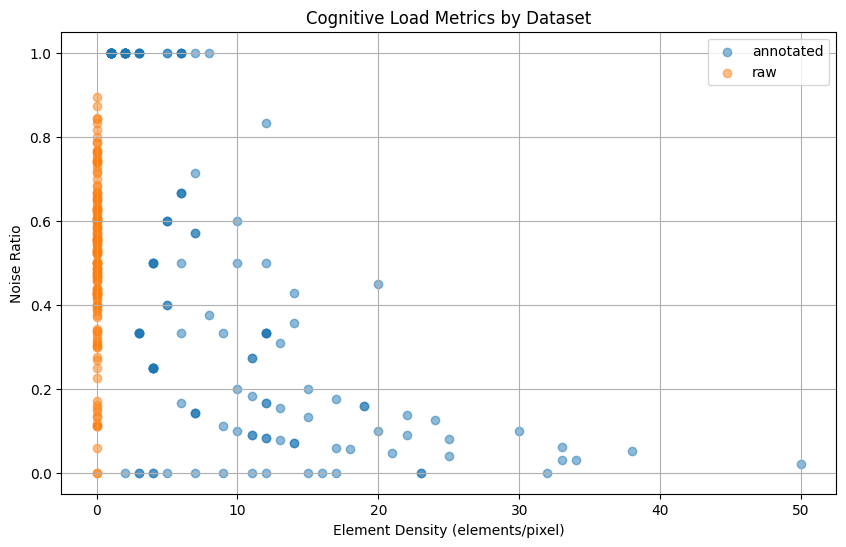


=== Optimizing Thresholds ===


,source,density_threshold,cluster_threshold,screens_retained,avg_reduction,score
0,raw,0.03,0.5,70,0.0789,0.1759



=== Evaluating Pruning ===

=== Results Summary ===
Screens processed: 300
Raw screens pruned: 80/150
Average reduction: 34.3%


In [20]:
# Cell 7: Main Pipeline (Configurable)
def run_full_pipeline(limit=300, params=None):
    """Complete pipeline with optional threshold tuning parameters"""
    print("=== Loading Data ===")
    annotated = load_rico_data(limit // 2, 'annotated')
    raw = load_rico_data(limit // 2, 'raw')
    all_screens = annotated + raw

    print("\n=== Analyzing Metrics ===")
    metrics_df = analyze_cognitive_load(all_screens)
    visualize_load_metrics(metrics_df)

    print("\n=== Optimizing Thresholds ===")
    thresholds = optimize_pruning_thresholds(metrics_df, params)
    display(thresholds)

    print("\n=== Evaluating Pruning ===")
    results_df, pruned_screens = evaluate_pruning_strategy(all_screens, metrics_df, thresholds)

    print("\n=== Results Summary ===")
    raw_count = len([s for s in all_screens if s['source'] == 'raw'])
    print(f"Screens processed: {len(all_screens)}")
    print(f"Raw screens pruned: {len(pruned_screens)}/{raw_count}")
    print(f"Average reduction: {results_df['reduction_pct'].mean():.1f}%")

    return {
        'metrics': metrics_df,
        'thresholds': thresholds,
        'results': results_df,
        'pruned_screens': pruned_screens,
        'raw_screens': raw  # <-- ADD THIS LINE
    }

# Configurable Parameters
balanced_params = {
    'density_range': (0.03, 0.15),     # Avoid overly strict pruning
    'noise_range': (0.2, 0.5),         # Moderate tolerance to fragmentation
    'target_coverage': 0.6,
    'reduction_weight': 0.75,          # Prioritize reduction more
    'min_samples': 10,
}

# Run pipeline with config
final_results = run_full_pipeline(limit=300, params=balanced_params)

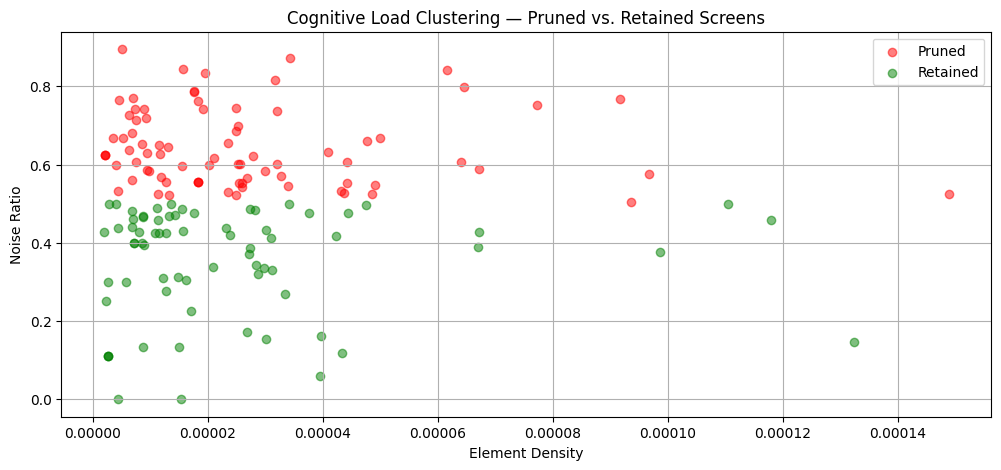

In [15]:
# Cell 8: Visualization
def plot_pruning_impact(results_df):
    plt.figure(figsize=(12, 5))
    pruned = results_df[results_df['was_pruned']]
    retained = results_df[~results_df['was_pruned']]

    plt.scatter(pruned['density'], pruned['noise_ratio'], color='red', alpha=0.5, label='Pruned')
    plt.scatter(retained['density'], retained['noise_ratio'], color='green', alpha=0.5, label='Retained')

    plt.xlabel("Element Density")
    plt.ylabel("Noise Ratio")
    plt.title("Cognitive Load Clustering — Pruned vs. Retained Screens")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_pruning_impact(final_results['results'])


Loading raw screens:  69%|██████▊   | 206/300 [00:00<00:00, 457.08it/s]

Skipping 51436.json: argument of type 'NoneType' is not iterable


Loading raw screens: 100%|██████████| 300/300 [00:00<00:00, 365.00it/s]


✅ Loaded 299 raw screens


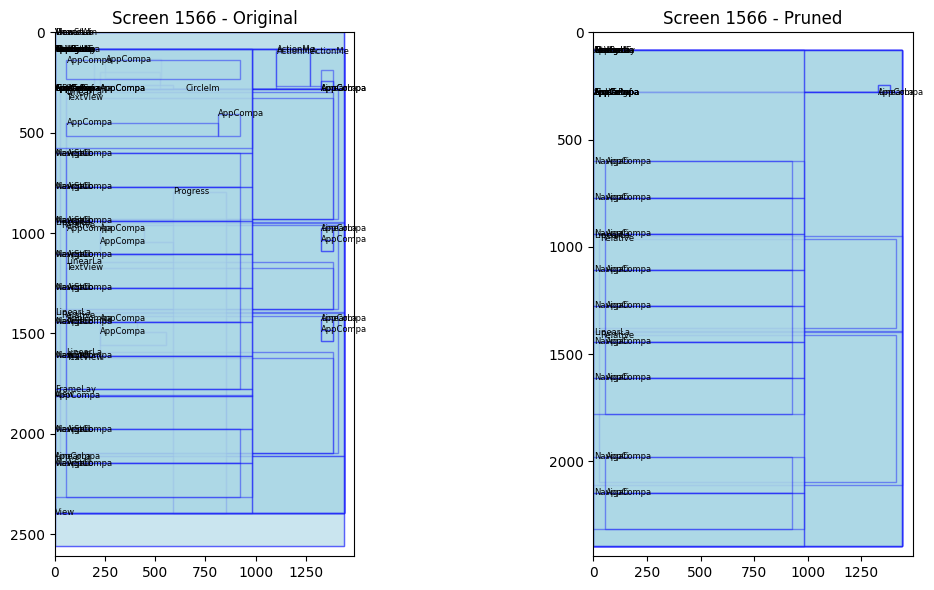

In [21]:
# Cell 9: Visual Comparison of Original vs Pruned UI Layouts
import matplotlib.patches as patches

def visualize_screen_comparison(original, pruned, title_prefix=""):
    """Generates side-by-side comparison of UI layouts before and after pruning
    
    Args:
        original: Dictionary containing original screen elements and metadata
        pruned: Dictionary containing pruned screen elements
        title_prefix: Optional string to prepend to plot titles
    """
    # Create figure with two subplots 
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  
    
    # Plot both original and pruned versions
    for ax, screen, title in zip(
        axes,                         # The two subplot axes
        [original, pruned],           # The screen data to visualize
        [f"{title_prefix}Original",   # Left plot title
         f"{title_prefix}Pruned"]     # Right plot title
    ):
        # Set plot title and boundaries
        ax.set_title(title)
        # Set x-axis limit 
        ax.set_xlim(0, max(e['bounds'][2] for e in screen['elements']) + 50)
        # Set y-axis limit 
        ax.set_ylim(0, max(e['bounds'][3] for e in screen['elements']) + 50)
        ax.invert_yaxis()  # Match mobile coordinate system (origin at top-left)
        ax.set_aspect('equal')  # Prevent distortion of UI elements
        
        # Draw each UI element as a semi-transparent rectangle
        for e in screen['elements']:
            xmin, ymin, xmax, ymax = e['bounds']
            # Create rectangle patch for the element
            rect = patches.Rectangle(
                (xmin, ymin),         
                xmax - xmin,          
                ymax - ymin,          
                linewidth=1,          
                edgecolor='blue',     
                facecolor='lightblue', 
                alpha=0.4             
            )
            ax.add_patch(rect)
            # Add element class name label 
            ax.text(
                xmin + 2,            
                ymin + 12,           
                e['class'][:8],       
                fontsize=6            
            )
    
    # Adjust layout and display
    plt.tight_layout()  # Prevent label overlapping
    plt.show()

# Example usage with pruning results
if final_results['pruned_screens']:
    # Select first pruned screen for demonstration
    sample = final_results['pruned_screens'][0]
    
    # Find matching original screen from different result sets
    original = next(s for s in final_results['metrics'].to_dict('records') 
                    if s['screen_id'] == sample['screen_id'])
    original_screen = next(s for s in final_results['results'].to_dict('records') 
                           if s['screen_id'] == sample['screen_id'])
    
    # Get full original UI data from raw dataset
    full_original = next(s for s in final_results['metrics'].to_dict('records')
                         if s['screen_id'] == sample['screen_id'])
    original_screen_data = next(s for s in load_rico_data(300, 'raw')
                                if s['screen_id'] == sample['screen_id'])
    
    # Generate comparison visualization
    visualize_screen_comparison(
        original=original_screen_data, 
        pruned=sample, 
        title_prefix=f"Screen {sample['screen_id']} - "
    )
else:
    print("⚠️ No pruned screens available for visualization.")

🔍 Analyzing UI class distributions...

=== UI Class Preservation (n=80) ===


,screen_id,jaccard_similarity,class_preservation,element_reduction
0,1566,0.607143,0.607143,0.565657
1,13182,0.500000,0.500000,0.727273
2,21762,0.760000,0.760000,0.541667
3,48692,0.538462,0.538462,0.616438
4,9340,0.833333,0.833333,0.582524
...,...,...,...,...
75,33917,0.875000,0.875000,0.555556
76,47889,0.470588,0.470588,0.560000
77,29676,0.722222,0.722222,0.627907
78,35494,0.562500,0.562500,0.872881



📊 Average Metrics:
• Jaccard Similarity: 0.64
• Class Preservation: 0.64
• Element Reduction: 0.64


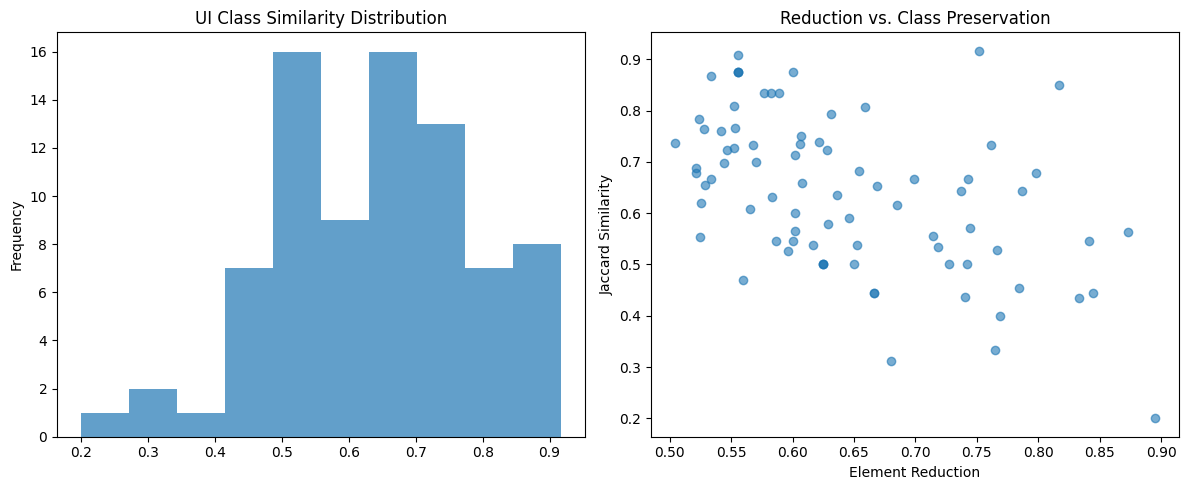


🔍 Class Distribution Samples:

Screen 1566:
Original (99 classes):
  PhoneWindow$DecorView
  LinearLayout
  ViewStub
  FrameLayout
  FitWindowsLinearLayout
  ViewStubCompat
  ContentFrameLayout
  DrawerLayout
  LinearLayout
  AppBarLayout...

Pruned (43 classes):
  FrameLayout
  FitWindowsLinearLayout
  ContentFrameLayout
  DrawerLayout
  LinearLayout
  AppBarLayout
  Toolbar
  SwipeRefreshLayout
  LinearLayout
  LinearLayout...

Screen 13182:
Original (22 classes):
  PhoneWindow$DecorView
  LinearLayout
  ViewStub
  FrameLayout
  LinearLayout
  ScrollView
  LinearLayout
  ImageView
  Button
  TextView...

Pruned (6 classes):
  PhoneWindow$DecorView
  LinearLayout
  FrameLayout
  LinearLayout
  ScrollView
  LinearLayout


In [22]:
# Cell 10: UI Element Class Preservation Analysis

# Import required libraries
from sklearn.feature_extraction.text import CountVectorizer  # For text feature extraction
from collections import Counter  # For counting class occurrences
import pandas as pd  # For data manipulation
import matplotlib.pyplot as plt  # For visualization

def extract_element_classes(screen):
    """Extracts and formats UI element class names with hierarchy information
    
    Args:
        screen: Dictionary containing UI elements data
        
    Returns: 
        Space-separated string of all class names in the screen
    """
    classes = []
    for element in screen['elements']:
        # Simplify class name by removing package prefix 
        class_name = element['class'].split('.')[-1]
        
        # Include parent-child relationship if available
        if 'parent-class' in element:
            parent_class = element['parent-class'].split('.')[-1]
            classes.append(f"{parent_class}>{class_name}")  
        else:
            classes.append(class_name)
    
    return " ".join(classes)  # Combine all classes into single string

def analyze_ui_classes(raw_screens, pruned_screens):
    """Analyzes how well UI element classes are preserved during pruning
    
    Args:
        raw_screens: List of original screen dictionaries
        pruned_screens: List of pruned screen dictionaries
        
    Returns:
        DataFrame containing preservation metrics for each screen pair
    """
    # Match original and pruned screens by screen_id
    pairs = []
    for raw in raw_screens:
        pruned = next((p for p in pruned_screens if p['screen_id'] == raw['screen_id']), None)
        if pruned:
            pairs.append((
                raw['screen_id'],  
                extract_element_classes(raw),  
                extract_element_classes(pruned),  
                len(raw['elements']),  
                len(pruned['elements'])  
            ))
    
    if not pairs:
        print("⚠️ No matching screen pairs found")
        return pd.DataFrame()

    # Convert class names to numerical features
    vectorizer = CountVectorizer(binary=True, max_features=200)  # Treat classes as binary features
    all_classes = [p[1] for p in pairs] + [p[2] for p in pairs]  # Combine all class strings
    vectorizer.fit(all_classes)  # Learn vocabulary from all classes
    
    # Calculate preservation metrics for each screen pair
    results = []
    for screen_id, raw_classes, pruned_classes, raw_count, pruned_count in pairs:
        raw_set = set(raw_classes.split())  # Unique original classes
        pruned_set = set(pruned_classes.split())  # Unique preserved classes
        
        # Jaccard similarity: intersection over union of class sets
        jaccard = len(raw_set & pruned_set) / max(1, len(raw_set | pruned_set))
        
        # Class preservation ratio: percentage of classes kept
        preservation = len(pruned_set) / max(1, len(raw_set))
        
        results.append({
            'screen_id': screen_id,
            'jaccard_similarity': jaccard,  
            'class_preservation': preservation,  
            'element_reduction': 1 - (pruned_count / raw_count),  
            'raw_classes': raw_classes,  # For debugging
            'pruned_classes': pruned_classes  # For debugging
        })
    
    metrics_df = pd.DataFrame(results)
    
    # Display results summary
    print(f"\n=== UI Class Preservation (n={len(metrics_df)}) ===")
    display(metrics_df[['screen_id', 'jaccard_similarity', 'class_preservation', 'element_reduction']])
    
    # Print average metrics
    print(f"\n📊 Average Metrics:")
    print(f"• Jaccard Similarity: {metrics_df['jaccard_similarity'].mean():.2f}")
    print(f"• Class Preservation: {metrics_df['class_preservation'].mean():.2f}")
    print(f"• Element Reduction: {metrics_df['element_reduction'].mean():.2f}")
    
    # Visualize results if we have multiple screens
    if len(metrics_df) > 1:
        plt.figure(figsize=(12, 5))
        
        # Histogram of Jaccard similarity scores
        plt.subplot(1, 2, 1)
        metrics_df['jaccard_similarity'].plot(kind='hist', bins=10, alpha=0.7)
        plt.title("UI Class Similarity Distribution")
        
        # Scatter plot: reduction vs preservation
        plt.subplot(1, 2, 2)
        plt.scatter(
            metrics_df['element_reduction'], 
            metrics_df['jaccard_similarity'],
            alpha=0.6
        )
        plt.title("Reduction vs. Class Preservation")
        plt.xlabel("Element Reduction")
        plt.ylabel("Jaccard Similarity")
        
        plt.tight_layout()
        plt.show()
    
    # Show detailed examples
    print("\n🔍 Class Distribution Samples:")
    sample_size = min(2, len(metrics_df))
    for _, row in metrics_df.head(sample_size).iterrows():
        print(f"\nScreen {row['screen_id']}:")
        print(f"Original ({len(row['raw_classes'].split())} classes):")
        print("  " + "\n  ".join(row['raw_classes'].split()[:10]) + ("..." if len(row['raw_classes'].split()) > 10 else ""))
        print(f"\nPruned ({len(row['pruned_classes'].split())} classes):")
        print("  " + "\n  ".join(row['pruned_classes'].split()[:10]) + ("..." if len(row['pruned_classes'].split()) > 10 else ""))
        
        # For single screen, show top 5 class preservation details
        if len(metrics_df) == 1:
            original_counts = Counter(row['raw_classes'].split())
            pruned_counts = Counter(row['pruned_classes'].split())
            print("\nClass Preservation Details:")
            for cls in sorted(original_counts, key=original_counts.get, reverse=True)[:5]:
                preserved = "✓" if cls in pruned_counts else "✗"
                print(f"{preserved} {cls}: {pruned_counts.get(cls, 0)}/{original_counts[cls]}")
    
    return metrics_df

# Execute analysis pipeline
print("🔍 Analyzing UI class distributions...")
metrics_df = analyze_ui_classes(
    final_results['raw_screens'],  # Original screens
    final_results['pruned_screens']  # Pruned screens
)

In [23]:
# Analysis of rico-dataset
import os
import json
from tqdm import tqdm

# Dataset Paths
RICO_PATH = '/kaggle/input/rico-dataset'
RICO_UI_PATH = f"{RICO_PATH}/unique_uis/combined"

# Directory Structure Diagnostics
def print_directory_structure(base_path):
    """Print the directory structure recursively, limiting the depth to avoid excessive output."""
    for root, dirs, files in os.walk(base_path):
        print(f"Directory: {root}")
        if len(files) > 10:
            print(f"  Files: {files[:5]}... (showing first 5 files only)")
        else:
            print(f"  Files: {files}")
        print("")

# Load and Inspect Sample JSONs
def load_json_samples(path, num_samples=5):
    """Load and print sample JSON data from a directory."""
    files = [f for f in os.listdir(path) if f.endswith('.json')]
    samples = files[:num_samples]

    for fname in samples:
        try:
            with open(os.path.join(path, fname), 'r', encoding='utf-8') as f:
                data = json.load(f)
                print(f"Sample data from {fname}:")
                print(json.dumps(data, indent=2)[:1000])  # Preview first 1000 characters
                print("\n" + "="*80 + "\n")
        except Exception as e:
            print(f"⚠️ Error loading {fname}: {str(e)}")

# Inspect RICO structure
print("📂 Inspecting RICO dataset structure...")
print_directory_structure(RICO_UI_PATH)

# Inspect samples from RICO
print("🔍 Inspecting sample RICO JSON files...")
load_json_samples(RICO_UI_PATH)

📂 Inspecting RICO dataset structure...
Directory: /kaggle/input/rico-dataset/unique_uis/combined
  Files: ['64601.jpg', '31973.jpg', '1566.json', '30778.jpg', '39342.json']... (showing first 5 files only)

🔍 Inspecting sample RICO JSON files...
Sample data from 1566.json:
{
  "activity_name": "com.androidcentral.app/com.androidcentral.app.ForumThreadActivity",
  "activity": {
    "root": {
      "scrollable-horizontal": false,
      "draw": true,
      "ancestors": [
        "android.widget.FrameLayout",
        "android.view.ViewGroup",
        "android.view.View",
        "java.lang.Object"
      ],
      "clickable": false,
      "pressed": "not_pressed",
      "focusable": false,
      "long-clickable": false,
      "enabled": true,
      "bounds": [
        0,
        0,
        1440,
        2560
      ],
      "visibility": "visible",
      "content-desc": [
        null
      ],
      "rel-bounds": [
        0,
        0,
        1440,
        2560
      ],
      "focused": fal

In [24]:
# Analysis of annotated-rico-dataset
import os
import json
from tqdm import tqdm
from collections import defaultdict

# Dataset Path
RICO_SEMANTICS_PATH = '/kaggle/input/annotated-rico-dataset/rico_semantics-main'

# Helper Functions
def print_directory_structure(base_path, max_depth=3, current_depth=0):
    """Print the directory structure recursively with limited depth."""
    if current_depth > max_depth:
        return
        
    prefix = "  " * current_depth
    try:
        items = os.listdir(base_path)
    except Exception as e:
        print(f"{prefix}⚠️ Error accessing {base_path}: {str(e)}")
        return
        
    for item in sorted(items):  # Sort for consistent output
        if item.startswith('.'):  # Skip hidden files
            continue
            
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            print(f"{prefix}📁 {item}/")
            print_directory_structure(item_path, max_depth, current_depth + 1)
        else:
            print(f"{prefix}📄 {item}")

def load_json_samples(path, num_samples=3):
    """Load and print sample JSON data from a directory."""
    json_files = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith('.json'):
                json_files.append(os.path.join(root, f))
    
    if not json_files:
        print("⚠️ No JSON files found in the dataset")
        return
    
    samples = sorted(json_files)[:num_samples]  # Sort for consistent sampling
    
    for fpath in samples:
        try:
            with open(fpath, 'r', encoding='utf-8') as f:
                data = json.load(f)
                print(f"\nSample data from {os.path.relpath(fpath, path)}:")
                if isinstance(data, list):
                    print(f"List with {len(data)} items")
                    if data:
                        print("First item:")
                        print(json.dumps(data[0], indent=2))
                elif isinstance(data, dict):
                    print("Dictionary with keys:", list(data.keys()))
                    if data:
                        print("First few items:")
                        print(json.dumps({k: data[k] for k in list(data.keys())[:3]}, indent=2))
                print("\n" + "="*80 + "\n")
        except Exception as e:
            print(f"⚠️ Error loading {fpath}: {str(e)}")

# Analysis Functions
def analyze_grouping_data(semantics_path):
    """Analyze the grouping data files (train/test/val)."""
    grouping_path = os.path.join(semantics_path, 'data', 'grouping')
    if not os.path.exists(grouping_path):
        return {}
    
    stats = {
        'total_screens': 0,
        'elements_per_screen': [],
        'label_counts': defaultdict(int),
        'split_counts': defaultdict(int)
    }
    
    for split in ['train', 'test', 'val']:
        file_path = os.path.join(grouping_path, f"{split}.json")
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                stats['split_counts'][split] = len(data)
                stats['total_screens'] += len(data)
                
                for screen in data:
                    elements = screen.get('screen_elements', [])
                    stats['elements_per_screen'].append(len(elements))
                    for element in elements:
                        stats['label_counts'][element.get('label', 'unknown')] += 1
        except Exception as e:
            print(f"⚠️ Error processing {file_path}: {str(e)}")
    
    # Calculate average elements per screen
    if stats['elements_per_screen']:
        avg_elements = sum(stats['elements_per_screen']) / len(stats['elements_per_screen'])
        stats['avg_elements_per_screen'] = round(avg_elements, 2)
    else:
        stats['avg_elements_per_screen'] = 0
    
    return stats

# Execute
print("📂 Directory Structure of RICO Semantics Dataset:")
print_directory_structure(RICO_SEMANTICS_PATH)
print("\n" + "="*80 + "\n")

print("🔍 Inspecting sample JSON files from the dataset...")
load_json_samples(RICO_SEMANTICS_PATH)
print("="*80 + "\n")

print("📊 Analyzing grouping data statistics...")
grouping_stats = analyze_grouping_data(RICO_SEMANTICS_PATH)
if grouping_stats:
    print("\nGrouping Data Statistics:")
    print(f"Total screens: {grouping_stats['total_screens']}")
    print(f"Screens per split: {dict(grouping_stats['split_counts'])}")
    print(f"Average elements per screen: {grouping_stats['avg_elements_per_screen']}")
    print("\nElement Label Counts:")
    for label, count in sorted(grouping_stats['label_counts'].items(), key=lambda x: x[1], reverse=True):
        print(f"{label}: {count}")
else:
    print("⚠️ No grouping data found")
print("\n" + "="*80 + "\n")

📂 Directory Structure of RICO Semantics Dataset:
📄 LICENSE
📄 README.md
📁 data/
  📁 grouping/
    📄 test.json
    📄 train.json
    📄 val.json
  📁 iconnet/
    📄 test.json
    📄 train.json
    📄 val.json
  📁 semantics/
    📄 test.json
    📄 train.json
    📄 val.json


🔍 Inspecting sample JSON files from the dataset...

Sample data from data/grouping/test.json:
List with 4239 items
First item:
{
  "screen_id": "63253",
  "screen_elements": []
}



Sample data from data/grouping/train.json:
List with 33738 items
First item:
{
  "screen_id": "15654",
  "screen_elements": [
    {
      "xmin": 0.04444444552063942,
      "ymin": 0.05677083507180214,
      "xmax": 0.0962962955236435,
      "ymax": 0.08541666716337204,
      "label": "ICON"
    },
    {
      "xmin": 0.33703702688217163,
      "ymin": 0.535937488079071,
      "xmax": 0.36666667461395264,
      "ymax": 0.5572916865348816,
      "label": "ICON"
    },
    {
      "xmin": 0.08055555820465088,
      "ymin": 0.6723958253860474,
    